# Set 12 - Trend, Saisonalität, Autokorrelation und Differenzierung

**Lernziele:** Strukturen einer Zeitreihe trennen, wiederkehrende Abstände erkennen und Stationarität vorsichtig beurteilen.

Wir analysieren nur den ersten Abschnitt einer synthetischen Sensorreihe. Die Zerlegung ist eine **nachträgliche Analyse des Trainingsabschnitts**, keine Prognosemethode. STL kann innerhalb dieses Abschnitts spätere Beobachtungen zur Glättung früherer Zeitpunkte verwenden.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

kandidaten = [Path.cwd(), *Path.cwd().parents]
set_ordner = next((p for basis in kandidaten
                   for p in (basis, basis / "set12-zeitreihenanalyse")
                   if (p / "zeitreihen_tools.py").exists()), None)
if set_ordner is None:
    raise FileNotFoundError("Notebook bitte innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:
    sys.path.insert(0, str(set_ordner))
from zeitreihen_tools import (FARBEN, plot_stil, zeitachse, synthetische_reihe,
                              lag_tabelle, metriken, lade_bike, lade_energie)
plot_stil()

In [2]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

daten = synthetische_reihe()
training = daten.iloc[:480]
y = training.wert
print("480 Stunden = 20 vollständige Tage; die spätere Reihe bleibt unangetastet.")

480 Stunden = 20 vollständige Tage; die spätere Reihe bleibt unangetastet.


## 1. Bekannte Bausteine in der Simulation

Ein additives Modell lautet `Messwert = Trend + saisonales Muster + Rest`. Ein Trend verändert das Niveau langsam; Saisonalität wiederholt sich mit festem zeitlichem Abstand. Ein Rest kann Rauschen, Ausreißer oder eine übersehene Struktur enthalten. Bei proportional wachsender Saisonamplitude wäre ein additives Modell oft ungeeignet.

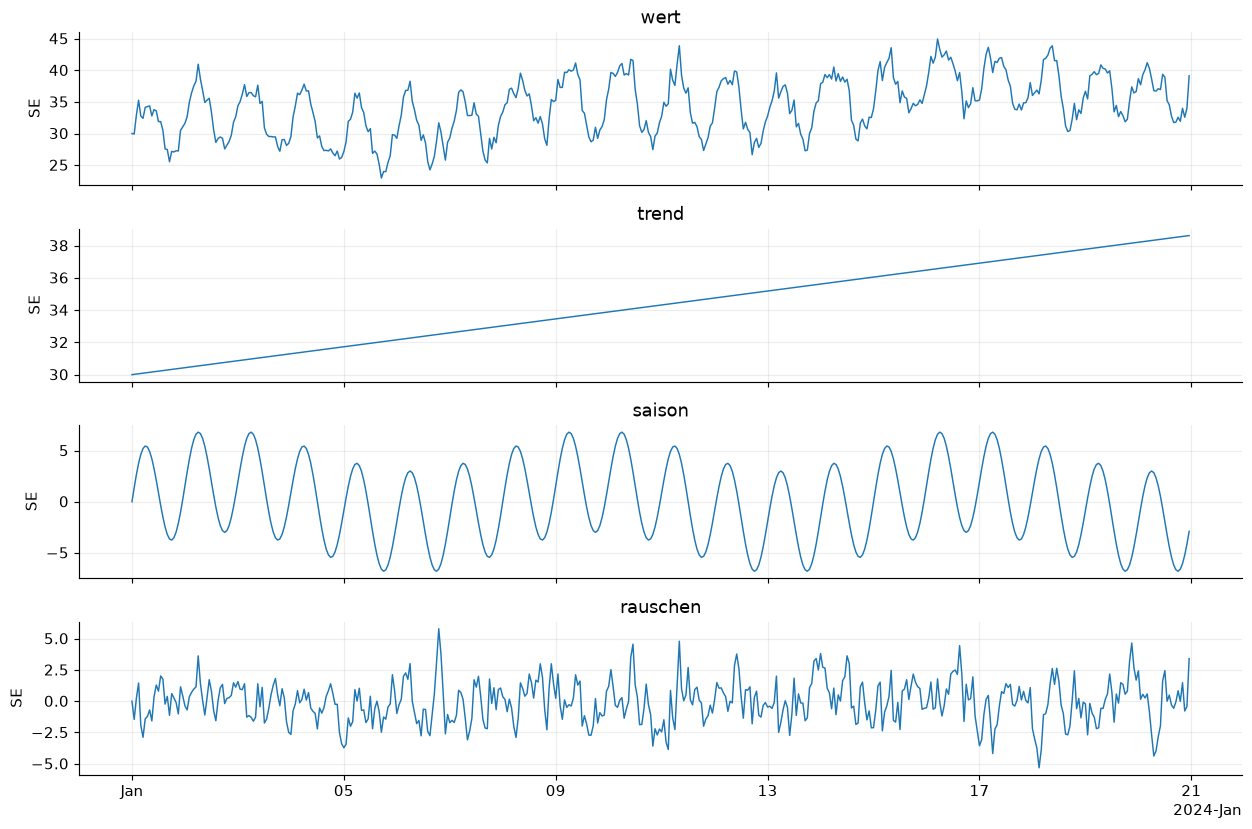

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, spalte in zip(axes, ["wert", "trend", "saison", "rauschen"]):
    ax.plot(training.index, training[spalte], lw=1)
    ax.set_ylabel("SE"); ax.set_title(spalte)
zeitachse(axes[-1]); plt.tight_layout(); plt.show()

## 2. STL lernt die Zerlegung aus der beobachteten Reihe

Wir geben `period=24` an, weil die Samples stündlich vorliegen und ein Tagesmuster erwartet wird. STL ermittelt die Periode nicht automatisch. Die Simulation enthält zusätzlich eine Wochenperiode (168 Stunden), die eine einzelne STL-Saison nicht vollständig abbildet. `robust=True` vermindert den Einfluss großer Ausschläge.

Verwechsele `period` (Länge eines Zyklus) nicht mit der Glättungsfensterbreite in Notebook 01.

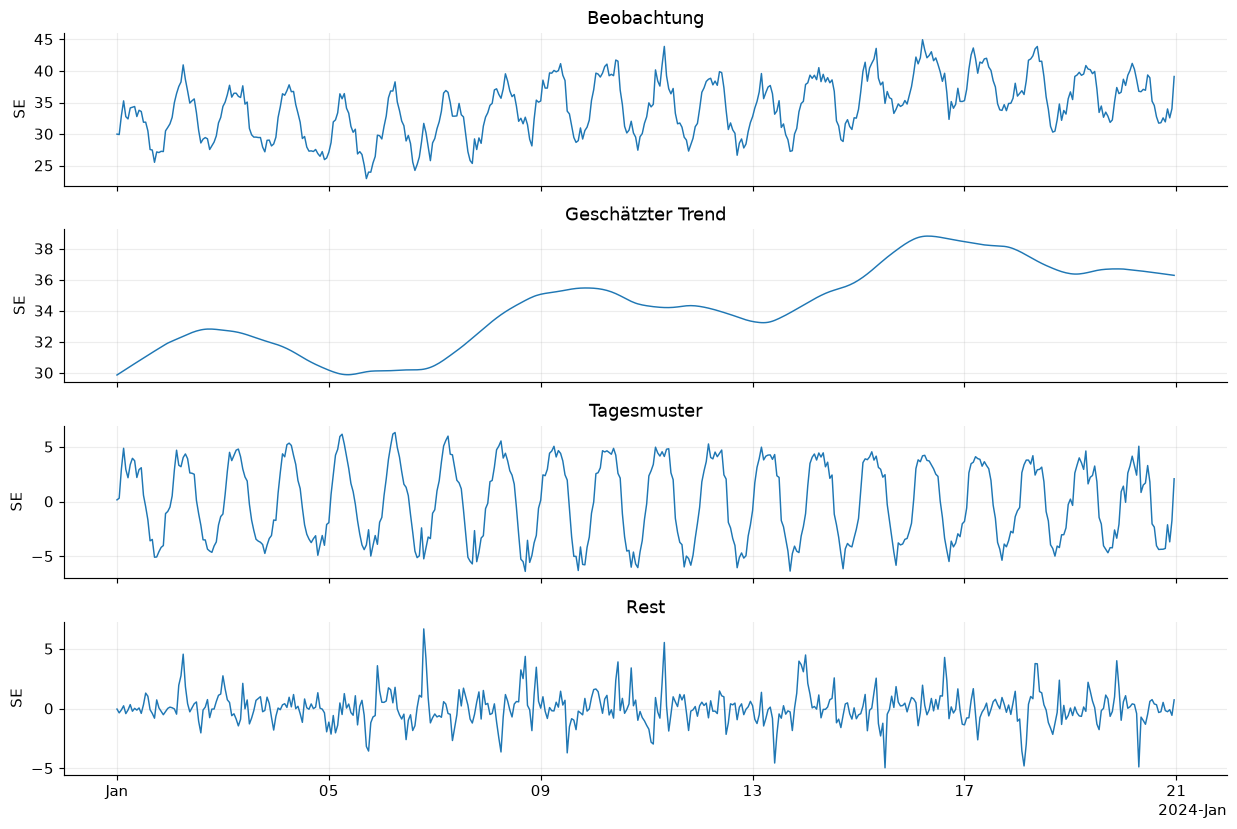

Mittlere absolute Rekonstruktionsabweichung: 8.141635513917814e-16


In [4]:
zerlegung = STL(y, period=24, robust=True).fit()
komponenten = pd.DataFrame({"Beobachtung":y, "Geschätzter Trend":zerlegung.trend,
                            "Tagesmuster":zerlegung.seasonal, "Rest":zerlegung.resid})
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, name in zip(axes, komponenten):
    ax.plot(komponenten.index, komponenten[name], lw=1)
    ax.set(title=name, ylabel="SE")
zeitachse(axes[-1]); plt.tight_layout(); plt.show()
print("Mittlere absolute Rekonstruktionsabweichung:",
      np.mean(np.abs(y - (zerlegung.trend + zerlegung.seasonal + zerlegung.resid))))

## 3. ACF und PACF: Wie hängt eine Reihe mit ihrer Vergangenheit zusammen?

Die Autokorrelation (ACF) vergleicht y[t] mit y[t-k]. Tagesmuster zeigen oft hohe Korrelation bei k=24, 48, ... Stunden. Die partielle Autokorrelation (PACF) betrachtet den Zusammenhang bei Lag k nach Kontrolle kürzerer Lags. Trend kann viele Lags hoch korrelieren lassen, ohne dass jeder Lag ein eigener Mechanismus ist.

Konfidenzbänder sind grobe inferenzielle Hilfen unter Modellannahmen, keine automatische Auswahlregel für ARIMA. Wir zeichnen zunächst die ACF der Rohreihe und des STL-Rests.

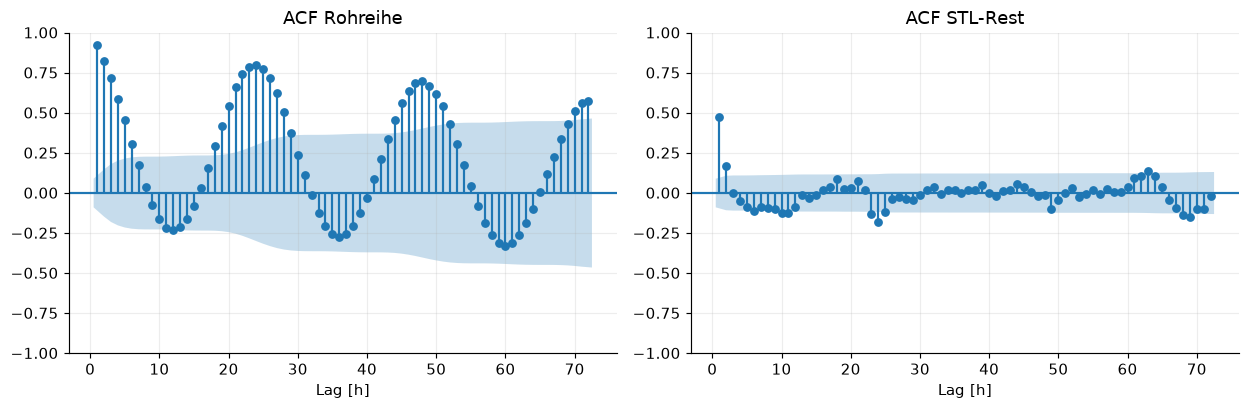

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=72, ax=axes[0], zero=False)
plot_acf(zerlegung.resid, lags=72, ax=axes[1], zero=False)
axes[0].set(title="ACF Rohreihe", xlabel="Lag [h]")
axes[1].set(title="ACF STL-Rest", xlabel="Lag [h]")
plt.tight_layout(); plt.show()

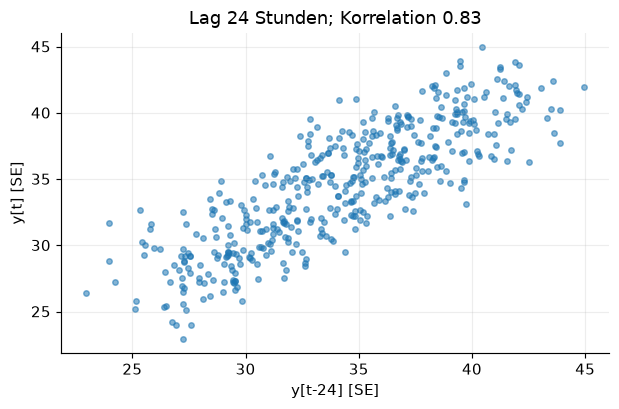

IntSlider(value=24, continuous_update=False, description='Lag [h]', max=168, min=1)

Output()

In [6]:
import ipywidgets as widgets

def zeige_lag(lag=24):
    vergleich = pd.DataFrame({"Vergangenheit":y.shift(lag), "Gegenwart":y}).dropna()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(vergleich.Vergangenheit, vergleich.Gegenwart, s=14, alpha=0.55)
    ax.set(xlabel=f"y[t-{lag}] [SE]", ylabel="y[t] [SE]",
           title=f"Lag {lag} Stunden; Korrelation {vergleich.corr().iloc[0,1]:.2f}")
    plt.tight_layout(); plt.show()

zeige_lag()
lag_regler = widgets.IntSlider(value=24, min=1, max=168, description="Lag [h]", continuous_update=False)
lag_ausgabe = widgets.interactive_output(zeige_lag, {"lag":lag_regler})
display(lag_regler, lag_ausgabe)

## 4. Differenzierung verändert die Fragestellung

`diff(1)` betrachtet die Veränderung gegenüber der letzten Stunde. `diff(24)` betrachtet die Veränderung gegenüber derselben Stunde des Vortags. Wir differenzieren zunächst saisonal, dann einmal zusätzlich. Dadurch gehen 25 Anfangswerte verloren. Stationarität heißt hier vereinfacht, dass sich Mittelwert, Streuung und die Abhängigkeitsstruktur nicht mit der Zeit verändern.

Differenzieren ist kein Selbstzweck: Zu häufiges Differenzieren kann unnötiges Rauschen erzeugen. Ein stabiler Mittelwert allein beweist keine Stationarität.

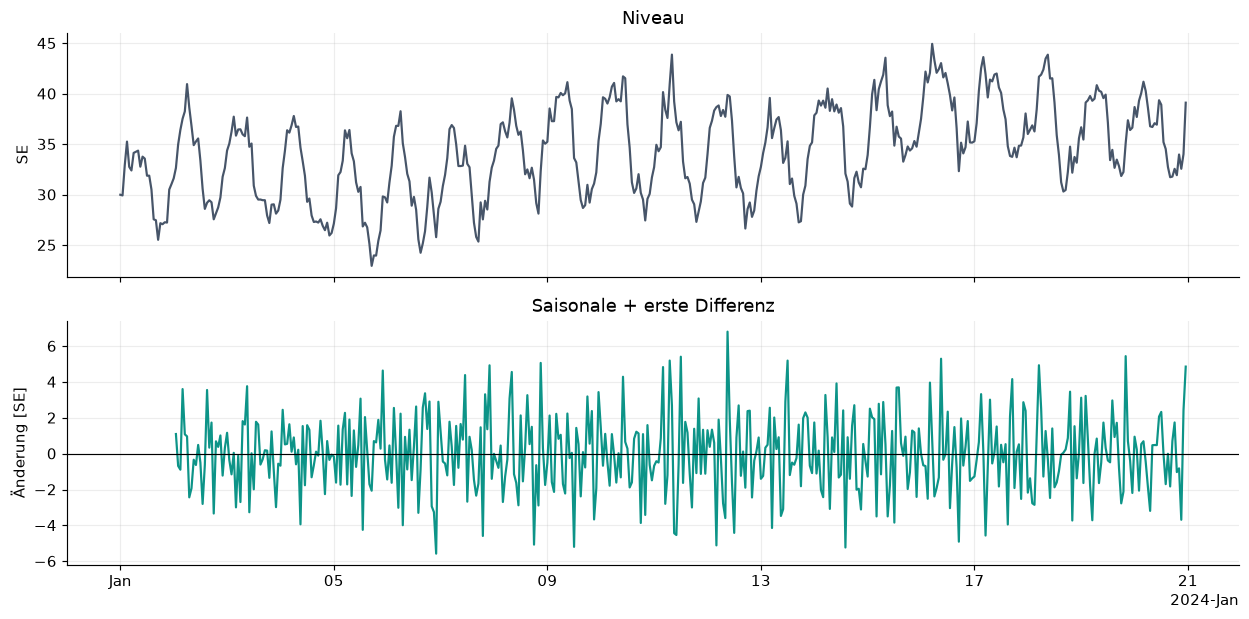

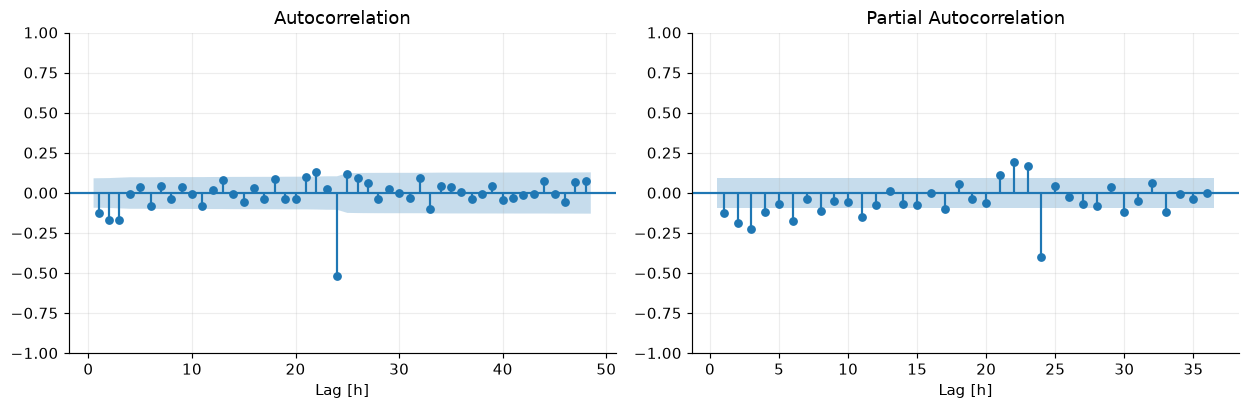

In [7]:
differenzen = y.diff(24).diff(1).dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(y, color=FARBEN["roh"]); axes[0].set(title="Niveau", ylabel="SE")
axes[1].plot(differenzen, color=FARBEN["saison"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(title="Saisonale + erste Differenz", ylabel="Änderung [SE]")
zeitachse(axes[-1]); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenzen, lags=48, ax=axes[0], zero=False)
plot_pacf(differenzen, lags=36, ax=axes[1], zero=False, method="ywm")
axes[0].set_xlabel("Lag [h]"); axes[1].set_xlabel("Lag [h]")
plt.tight_layout(); plt.show()

## 5. ADF als ergänzender Test

Der Augmented-Dickey-Fuller-Test hat als Nullhypothese eine Einheitswurzel. Ein kleiner p-Wert spricht gegen diese Nullhypothese unter der gewählten Testspezifikation. Er beweist keine vollständige Stationarität und keine Prognosegüte. Hier vergleichen wir einen Test mit konstantem Term (`regression="c"`); eine Trend-Spezifikation würde eine andere Frage stellen.

In [8]:
ergebnisse = []
for name, serie in {"Rohreihe":y, "Differenziert":differenzen}.items():
    test = adfuller(serie, regression="c", autolag="AIC")
    ergebnisse.append({"Reihe":name, "ADF-Statistik":test[0], "p-Wert":test[1], "verwendete Lags":test[2]})
display(pd.DataFrame(ergebnisse).set_index("Reihe").round(4))

C:\Users\yanni\AppData\Local\Temp\ipykernel_20816\1063652837.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  test = adfuller(serie, regression="c", autolag="AIC")
C:\Users\yanni\AppData\Local\Temp\ipykernel_20816\1063652837.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  test = adfuller(serie, regression="c", autolag="AIC")


,ADF-Statistik,p-Wert,verwendete Lags
Reihe,,,
Rohreihe,-1.7854,0.3877,18
Differenziert,-10.0531,0.0000,11


## Kleine Aufgaben
1. Stelle die STL-Periode auf 48. Was wird schlechter oder anders erklärt?
2. Vergleiche im Lag-Regler 1, 12, 24 und 168 Stunden.
3. Weshalb darf die STL-Zerlegung der gesamten Reihe nicht unbemerkt als Trainingsmerkmal dienen?
4. Erkläre die Grenzen eines Stationaritätstests und den Unterschied zwischen ACF und PACF.

API-Referenzen: [STL](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html), [ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html).